In [1]:
from pathlib import Path
import os

IMAGES_PATH = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")
images_path = Path(IMAGES_PATH)

images_path = Path(images_path)
labeled_images = {}

cloud_dir = list(images_path.iterdir())[0]

print(cloud_dir)

img_path = list(cloud_dir.iterdir())[0]

print(img_path)


../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Sc
../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Sc/116-192578-65509696-202005111737_GS_Sc.jpg


In [2]:
import torch
from PIL import Image
import torchvision.transforms as transforms

image = Image.open(img_path)

to_tensor_transform = transforms.Compose([
    transforms.PILToTensor()
])

img_tensor = to_tensor_transform(image)

# print the converted Torch tensor
print(img_tensor)


tensor([[[183, 183, 183,  ..., 194, 193, 193],
         [183, 183, 183,  ..., 194, 193, 193],
         [183, 183, 183,  ..., 194, 193, 193],
         ...,
         [ 16,  13,  11,  ...,  26,  24,  23],
         [ 13,  10,  10,  ...,  26,  24,  23],
         [ 11,   9,   9,  ...,  27,  25,  24]],

        [[197, 197, 197,  ..., 207, 206, 206],
         [197, 197, 197,  ..., 207, 206, 206],
         [197, 197, 197,  ..., 207, 206, 206],
         ...,
         [ 22,  19,  17,  ...,  22,  20,  19],
         [ 19,  16,  16,  ...,  22,  20,  19],
         [ 17,  15,  15,  ...,  23,  21,  20]],

        [[210, 210, 210,  ..., 224, 223, 223],
         [210, 210, 210,  ..., 224, 223, 223],
         [210, 210, 210,  ..., 224, 223, 223],
         ...,
         [  8,   5,   3,  ...,  19,  17,  16],
         [  5,   2,   2,  ...,  19,  17,  16],
         [  3,   1,   1,  ...,  20,  18,  17]]], dtype=torch.uint8)


In [3]:
import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14

# translation with black borders
border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# translation with wrap/repeat
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),  # dy
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),  # dx
    ),
    dims=(-2, -1),
))

# stacked pipeline
stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20,
        scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
    T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02),
])

# one of pipeline
one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([
        T.RandomHorizontalFlip(p=1.0),
        T.RandomVerticalFlip(p=1.0),
    ]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
    T.ColorJitter(brightness=0.20),
    T.ColorJitter(contrast=0.20),
    T.ColorJitter(saturation=0.15),
])

# alternating between modes
augmentation_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
])

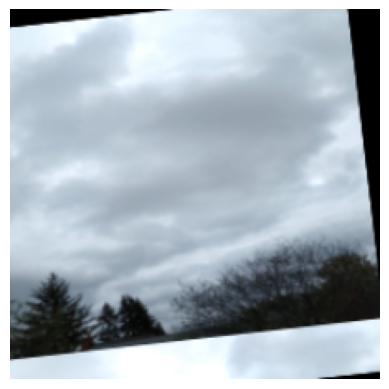

In [6]:
import matplotlib.pyplot as plt

augmented_img = augmentation_transform(img_tensor)


def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plot_image(augmented_img)
plt.show()
